# 🔥 California Wildfire Risk Prediction
**Model:** XGBoost Classifier  
**Grid:** 0.05° spatial resolution across California  
**Temporal:** Monthly, January 2012 – January 2025  
**Train:** Jan 2012 – Dec 2021 (10 years)  
**Test:** Jan 2022 – Jan 2025 (3 years)  
**Target:** `fire_occurred` (binary classification)

## 1. Setup & Install Dependencies

In [ ]:
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn joblib -q

In [2]:
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
import os
import json
import joblib
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay
)

print('Libraries loaded.')

Libraries loaded.


## 2. Mount Google Drive & Set Data Paths
Upload your CSVs to Google Drive, then update `DATA_DIR` below.

In [4]:
FIRE_CSV      = "/content/drive/MyDrive/wildfire_project/data/ca_fire_monthly_2012_2025.csv"
WEATHER_CSV   = "/content/drive/MyDrive/wildfire_project/data/california_monthly_weather.csv"
ELEVATION_CSV = "/content/drive/MyDrive/wildfire_project/data/elevation_grid.csv"
NDVI_CSV      = "/content/drive/MyDrive/wildfire_project/data/ndvi.csv"
print('Paths configured.')

Paths configured.


## 3. Load Data

In [5]:
fire      = pd.read_csv(FIRE_CSV,      parse_dates=['year_month'])
weather   = pd.read_csv(WEATHER_CSV,   parse_dates=['year_month'])
elevation = pd.read_csv(ELEVATION_CSV)
ndvi      = pd.read_csv(NDVI_CSV,      parse_dates=['time'])
ndvi      = ndvi.rename(columns={'time': 'year_month'})

print(f'Fire      : {len(fire):,} rows')
print(f'Weather   : {len(weather):,} rows')
print(f'Elevation : {len(elevation):,} rows')
print(f'NDVI      : {len(ndvi):,} rows')

Fire      : 6,234,470 rows
Weather   : 4,834,368 rows
Elevation : 39,710 rows
NDVI      : 6,194,760 rows


## 4. Merge into a Single Feature Table

In [6]:
df = fire[['grid_id', 'year_month', 'lat', 'lon', 'fire_occurred', 'burned_area_m2']].copy()

weather_cols = ['grid_id', 'year_month',
                'temp_c', 'precip_mm', 'wind_speed_ms', 'soil_moisture', 'solar_radiation']
df = df.merge(weather[weather_cols], on=['grid_id', 'year_month'], how='left')

elev_cols = ['grid_id', 'elevation_m', 'slope_deg', 'aspect_deg']
df = df.merge(elevation[elev_cols], on='grid_id', how='left')

ndvi_cols = ['grid_id', 'year_month', 'ndvi']
df = df.merge(ndvi[ndvi_cols], on=['grid_id', 'year_month'], how='left')

print(f'Merged shape: {df.shape}')
df.head(3)

Merged shape: (6234470, 15)


,grid_id,year_month,lat,lon,fire_occurred,burned_area_m2,temp_c,precip_mm,wind_speed_ms,soil_moisture,solar_radiation,elevation_m,slope_deg,aspect_deg,ndvi
0,000_000,2012-01-01,32.525,-124.475,0,0.0,NaN,NaN,NaN,NaN,NaN,1063.184814,0.0,180.0,NaN
1,000_000,2012-02-01,32.525,-124.475,0,0.0,NaN,NaN,NaN,NaN,NaN,1063.184814,0.0,180.0,NaN
2,000_000,2012-03-01,32.525,-124.475,0,0.0,NaN,NaN,NaN,NaN,NaN,1063.184814,0.0,180.0,NaN


## 5. Feature Engineering

In [7]:
df['month']       = df['year_month'].dt.month
df['year']        = df['year_month'].dt.year
df['month_sin']   = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos']   = np.cos(2 * np.pi * df['month'] / 12)
df['fire_season'] = df['month'].between(6, 10).astype(int)
df['aspect_sin']  = np.sin(np.deg2rad(df['aspect_deg']))
df['aspect_cos']  = np.cos(np.deg2rad(df['aspect_deg']))

df = df.sort_values(['grid_id', 'year_month'])
for col in ['temp_c', 'precip_mm', 'wind_speed_ms', 'soil_moisture', 'ndvi']:
    df[f'{col}_lag1'] = df.groupby('grid_id')[col].shift(1)

df['precip_roll3'] = (
    df.groupby('grid_id')['precip_mm']
      .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

print('Feature engineering complete.')
print(list(df.columns))

Feature engineering complete.
['grid_id', 'year_month', 'lat', 'lon', 'fire_occurred', 'burned_area_m2', 'temp_c', 'precip_mm', 'wind_speed_ms', 'soil_moisture', 'solar_radiation', 'elevation_m', 'slope_deg', 'aspect_deg', 'ndvi', 'month', 'year', 'month_sin', 'month_cos', 'fire_season', 'aspect_sin', 'aspect_cos', 'temp_c_lag1', 'precip_mm_lag1', 'wind_speed_ms_lag1', 'soil_moisture_lag1', 'ndvi_lag1', 'precip_roll3']


## 6. Train / Test Split
Temporal split: **train ≤ 2021-12**, **test ≥ 2022-01**

In [8]:
TRAIN_END  = pd.Timestamp('2021-12-31')
TEST_START = pd.Timestamp('2022-01-01')

train_df = df[df['year_month'] <= TRAIN_END].copy()
test_df  = df[df['year_month'] >= TEST_START].copy()

print(f'Train: {train_df["year_month"].min().date()} to {train_df["year_month"].max().date()}  ({len(train_df):,} rows)')
print(f'Test : {test_df["year_month"].min().date()} to {test_df["year_month"].max().date()}  ({len(test_df):,} rows)')
print(f'Fire rate -- train: {train_df["fire_occurred"].mean():.4%} | test: {test_df["fire_occurred"].mean():.4%}')

Train: 2012-01-01 to 2021-12-01  (4,765,200 rows)
Test : 2022-01-01 to 2025-01-01  (1,469,270 rows)
Fire rate -- train: 0.0472% | test: 0.0189%


In [9]:
FEATURES = [
    'lat', 'lon',
    'temp_c', 'precip_mm', 'wind_speed_ms', 'soil_moisture', 'solar_radiation',
    'elevation_m', 'slope_deg', 'aspect_sin', 'aspect_cos',
    'ndvi',
    'month_sin', 'month_cos', 'fire_season', 'year',
    'temp_c_lag1', 'precip_mm_lag1', 'wind_speed_ms_lag1',
    'soil_moisture_lag1', 'ndvi_lag1', 'precip_roll3',
]
TARGET = 'fire_occurred'

X_train = train_df[FEATURES]
y_train = train_df[TARGET]
X_test  = test_df[FEATURES]
y_test  = test_df[TARGET]

print(f'Features : {len(FEATURES)}')
print(f'Train NaN: {X_train.isna().mean().mean():.2%}')
print(f'Test  NaN: {X_test.isna().mean().mean():.2%}')

Features : 22
Train NaN: 17.91%
Test  NaN: 17.81%


## 7. Train XGBoost Model

In [22]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw_soft = np.sqrt(neg / pos)
print(f'scale_pos_weight = {spw_soft:.1f}  (neg={neg:,}, pos={pos:,})')

model = XGBClassifier(
    n_estimators          = 1000,
    max_depth             = 3,
    learning_rate         = 0.02,
    subsample             = 0.7,
    colsample_bytree      = 0.7,
    min_child_weight      = 30,
    gamma                 = 1.0,
    reg_alpha             = 0.1,
    reg_lambda            = 5.0,
    scale_pos_weight      = spw_soft,
    max_delta_step        = 1,
    eval_metric           = 'logloss',
    early_stopping_rounds = 30,
    random_state          = 42,
    tree_method           = 'hist',
    n_jobs                = -1,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)
print('Training complete.')

scale_pos_weight = 46.0  (neg=4,762,951, pos=2,249)
[0]	validation_0-logloss:0.13551
[50]	validation_0-logloss:0.06338
[100]	validation_0-logloss:0.03883
[150]	validation_0-logloss:0.02960
[200]	validation_0-logloss:0.02635
[250]	validation_0-logloss:0.02518
[300]	validation_0-logloss:0.02469
[350]	validation_0-logloss:0.02471
[352]	validation_0-logloss:0.02475
Training complete.


In [ ]:
from sklearn.calibration import CalibratedClassifierCV

# After fitting base model, calibrate on a held-out validation set
# (use a portion of your train set as cal_set)
model = CalibratedClassifierCV(model, method='isotonic', cv='prefit')
#cal_model.fit(X_cal, y_cal)  # X_cal/y_cal = held-out calibration set

# Use cal_model.predict_proba() for maps

## 8. Save Model

In [23]:
MODEL_PATH = '/content/drive/MyDrive/wildfire_project/model/wildfire_xgb.joblib'
joblib.dump(model, MODEL_PATH)
print(f'Model saved: {MODEL_PATH}')

with open('/content/drive/MyDrive/wildfire_project/model/feature_list.json', 'w') as f:
    json.dump(FEATURES, f, indent=2)
print('Feature list saved: /content/drive/MyDrive/wildfire_project/model/feature_list.json')

Model saved: /content/drive/MyDrive/wildfire_project/model/wildfire_xgb.joblib
Feature list saved: /content/drive/MyDrive/wildfire_project/model/feature_list.json


## 9. Evaluate on Test Set

In [13]:
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print(f'ROC-AUC : {roc_auc_score(y_test, y_prob):.4f}')
print(f'PR-AUC  : {average_precision_score(y_test, y_prob):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['No Fire', 'Fire']))

NameError: name 'model' is not defined

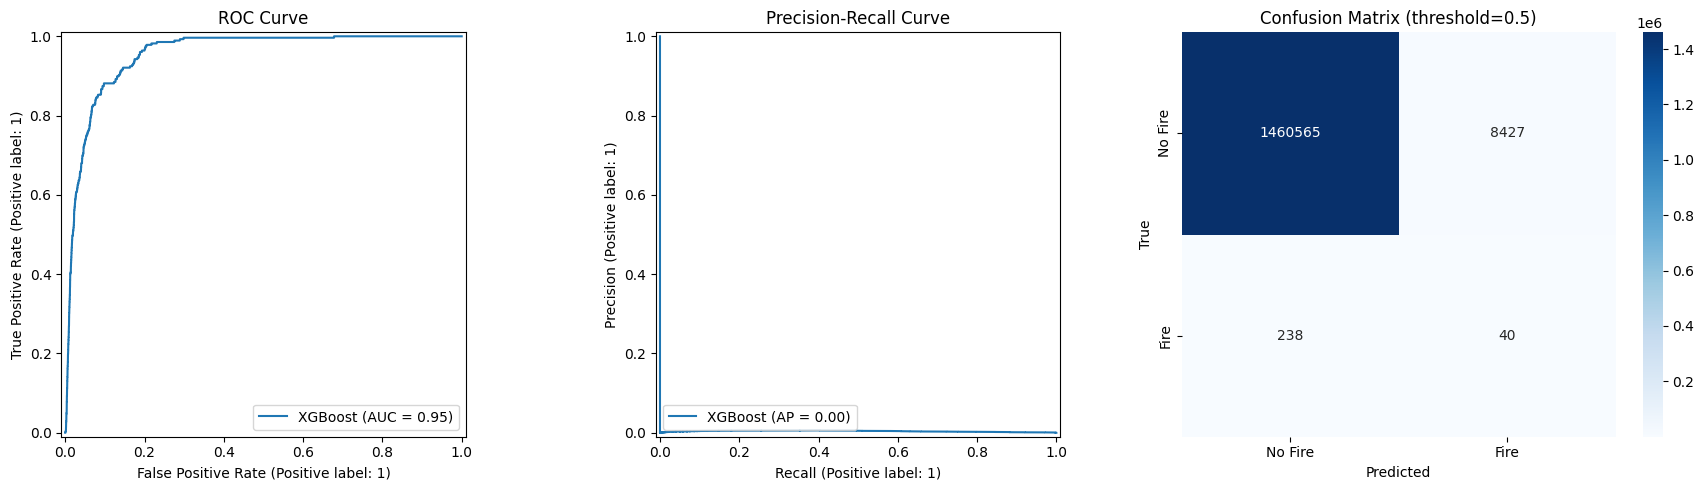

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[0], name='XGBoost')
axes[0].set_title('ROC Curve')

PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[1], name='XGBoost')
axes[1].set_title('Precision-Recall Curve')

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Fire', 'Fire'],
            yticklabels=['No Fire', 'Fire'], ax=axes[2])
axes[2].set_title('Confusion Matrix (threshold=0.5)')
axes[2].set_ylabel('True')
axes[2].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/wildfire_project/output/evaluation_curves.png', dpi=150)
plt.show()

In [1]:
importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('XGBoost Feature Importances (gain)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/wildfire_project/output/feature_importance.png', dpi=150)
plt.show()

NameError: name 'pd' is not defined

## 10. Predict Fire Risk for a Recent Year (2024)
Generates monthly fire-risk probability maps for each grid cell.

In [26]:
PREDICT_YEAR = 2024

predict_df    = df[df['year'] == PREDICT_YEAR].copy()
predict_clean = predict_df.dropna(subset=FEATURES).copy()
print(f'Rows for {PREDICT_YEAR}: {len(predict_df):,}  (after dropna: {len(predict_clean):,})')

predict_clean['fire_risk_prob'] = model.predict_proba(predict_clean[FEATURES])[:, 1]
predict_clean[['grid_id','year_month','lat','lon','fire_risk_prob']].head(5)

Rows for 2024: 476,520  (after dropna: 199,379)


,grid_id,year_month,lat,lon,fire_risk_prob
89163,002_149,2024-01-01,32.625,-117.025,0.003042
89164,002_149,2024-02-01,32.625,-117.025,0.002146
89165,002_149,2024-03-01,32.625,-117.025,0.002157
89166,002_149,2024-04-01,32.625,-117.025,0.002248
89167,002_149,2024-05-01,32.625,-117.025,0.002908


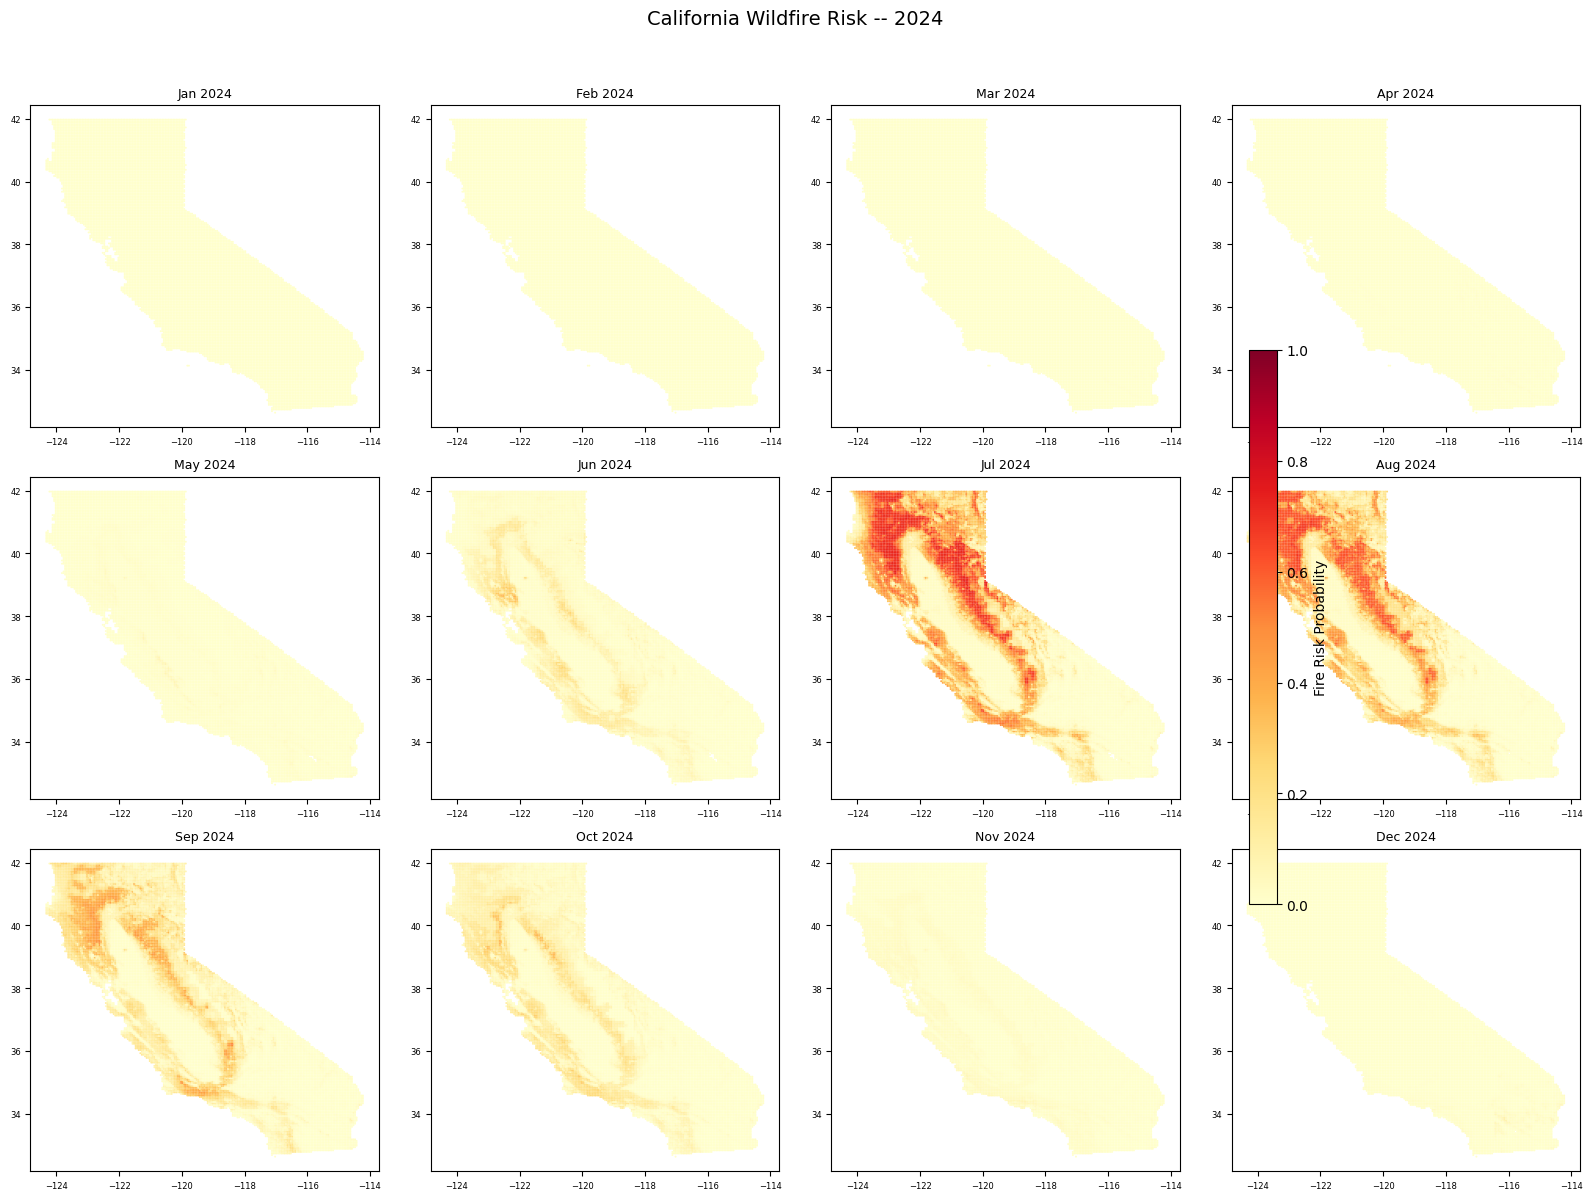

In [27]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
months = sorted(predict_clean['month'].unique())
ncols  = 4
nrows  = int(np.ceil(len(months) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for i, m in enumerate(months):
    sub = predict_clean[predict_clean['month'] == m]
    sc  = axes[i].scatter(
        sub['lon'], sub['lat'],
        c=sub['fire_risk_prob'], cmap='YlOrRd',
        vmin=0, vmax=1, s=2, linewidths=0
    )
    axes[i].set_title(f'{month_names[m-1]} {PREDICT_YEAR}', fontsize=9)
    axes[i].set_aspect('equal')
    axes[i].tick_params(labelsize=6)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.colorbar(sc, ax=axes[:len(months)], shrink=0.6, label='Fire Risk Probability')
fig.suptitle(f'California Wildfire Risk -- {PREDICT_YEAR}', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'/content/drive/MyDrive/wildfire_project/output/fire_risk_{PREDICT_YEAR}.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
out_cols = ['grid_id', 'year_month', 'lat', 'lon', 'month', 'fire_occurred', 'fire_risk_prob']
out_path = f'/content/drive/MyDrive/wildfire_project/output/fire_risk_predictions_{PREDICT_YEAR}.csv'
predict_clean[out_cols].to_csv(out_path, index=False)
print(f'Predictions saved: {out_path}')

Predictions saved: /content/drive/MyDrive/wildfire_project/output/fire_risk_predictions_2024.csv


## 11. (Optional) Load Saved Model & Run Inference
Use this block in a fresh session to skip retraining.

In [12]:
import joblib, json

loaded_model    = joblib.load('/content/drive/MyDrive/wildfire_project/model/wildfire_xgb.joblib')
with open('/content/drive/MyDrive/wildfire_project/model/feature_list.json') as f:
    loaded_features = json.load(f)

print('Model loaded. Features:', loaded_features[:5], '...')
# new_data['fire_risk_prob'] = loaded_model.predict_proba(new_data[loaded_features])[:, 1]

Model loaded. Features: ['lat', 'lon', 'temp_c', 'precip_mm', 'wind_speed_ms'] ...
